In [1]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving Country-data.csv to Country-data.csv
{'Country-data.csv': b'country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp\r\nAfghanistan,90.2,10,7.58,44.9,1610,9.44,56.2,5.82,553\r\nAlbania,16.6,28,6.55,48.6,9930,4.49,76.3,1.65,4090\r\nAlgeria,27.3,38.4,4.17,31.4,12900,16.1,76.5,2.89,4460\r\nAngola,119,62.3,2.85,42.9,5900,22.4,60.1,6.16,3530\r\nAntigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200\r\nArgentina,14.5,18.9,8.1,16,18700,20.9,75.8,2.37,10300\r\nArmenia,18.1,20.8,4.4,45.3,6700,7.77,73.3,1.69,3220\r\nAustralia,4.8,19.8,8.73,20.9,41400,1.16,82,1.93,51900\r\nAustria,4.3,51.3,11,47.8,43200,0.873,80.5,1.44,46900\r\nAzerbaijan,39.2,54.3,5.88,20.7,16000,13.8,69.1,1.92,5840\r\nBahamas,13.8,35,7.89,43.7,22900,-0.393,73.8,1.86,28000\r\nBahrain,8.6,69.5,4.97,50.9,41100,7.44,76,2.16,20700\r\nBangladesh,49.4,16,3.52,21.8,2440,7.14,70.4,2.33,758\r\nBarbados,14.2,39.5,7.97,48.7,15300,0.321,76.7,1.78,16000\r\nBelarus,5.5,51.4,5.61,64.5,16200,15.1,7

# t-SNE on Country Development Dataset

## Objective

The objective of this notebook is to implement t-SNE (t-Distributed Stochastic Neighbor Embedding) for dimensionality reduction and visualization of high-dimensional country data.

t-SNE helps visualize complex datasets by representing them in a lower-dimensional space while preserving local relationships between data points.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [3]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [6]:
countries = df["country"]

X = df.drop("country", axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Feature Scaling

Since the dataset contains features with different scales, standardization is performed before applying t-SNE.

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Applying t-SNE

The original dataset contains 9 features.

t-SNE reduces the dataset to 2 dimensions while attempting to preserve the relationships between similar countries.

In [8]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)

In [9]:
print("Original Shape :", X_scaled.shape)
print("Reduced Shape  :", X_tsne.shape)

Original Shape : (167, 9)
Reduced Shape  : (167, 2)


In [10]:
tsne_df = pd.DataFrame(
    X_tsne,
    columns=[
        "tSNE Component 1",
        "tSNE Component 2"
    ]
)

tsne_df.head()

,tSNE Component 1,tSNE Component 2
0,-11.646189,3.604757
1,1.092355,-2.302142
2,-3.783050,-1.923819
3,-8.959445,4.173811
4,3.560047,-1.521817


In [11]:
tsne_df["Country"] = countries

tsne_df.head()

,tSNE Component 1,tSNE Component 2,Country
0,-11.646189,3.604757,Afghanistan
1,1.092355,-2.302142,Albania
2,-3.783050,-1.923819,Algeria
3,-8.959445,4.173811,Angola
4,3.560047,-1.521817,Antigua and Barbuda


## t-SNE Visualization

Each point represents a country.

Countries located close together have similar socioeconomic characteristics.

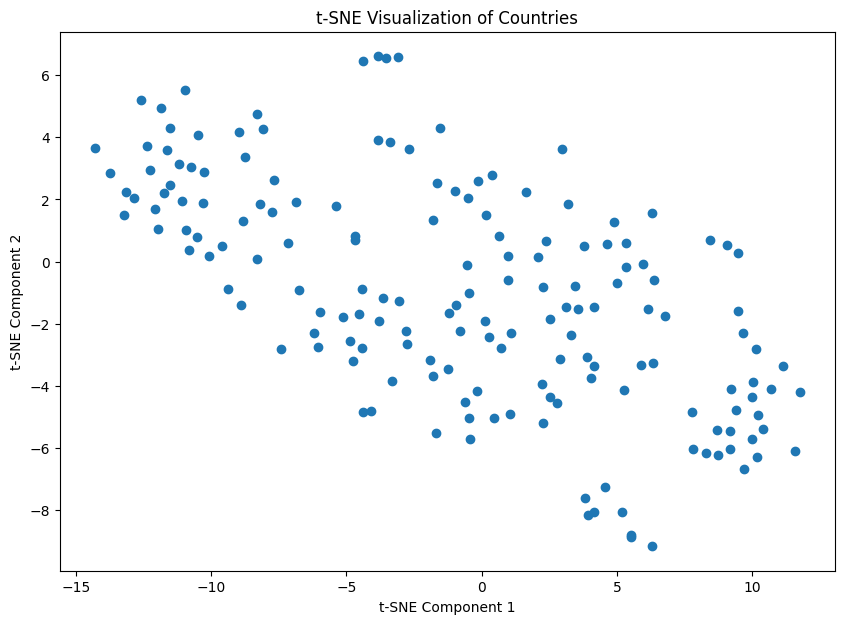

In [12]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1]
)

plt.title("t-SNE Visualization of Countries")

plt.xlabel("t-SNE Component 1")

plt.ylabel("t-SNE Component 2")

plt.show()

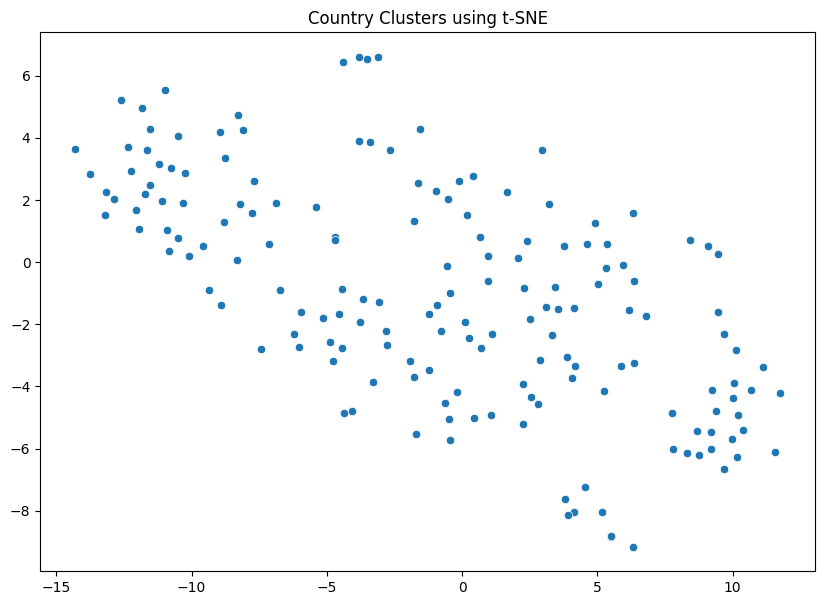

In [13]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1]
)

plt.title("Country Clusters using t-SNE")

plt.show()

In [14]:
tsne_df.head(15)

,tSNE Component 1,tSNE Component 2,Country
0,-11.646189,3.604757,Afghanistan
1,1.092355,-2.302142,Albania
2,-3.783050,-1.923819,Algeria
3,-8.959445,4.173811,Angola
4,3.560047,-1.521817,Antigua and Barbuda
5,-1.702602,-5.523870,Argentina
6,-1.217058,-1.665643,Armenia
7,10.163424,-6.285751,Australia
8,10.043445,-3.874825,Austria
9,-3.073753,-1.277961,Azerbaijan


## Interpretation

t-SNE attempts to place similar countries close together in the lower-dimensional space.

Countries with similar economic and social indicators tend to form visible groups.

Unlike PCA, t-SNE focuses more on preserving local relationships between nearby points, which often results in clearer cluster visualization.

## PCA vs t-SNE

PCA:
- Linear dimensionality reduction technique.
- Faster computation.
- Preserves overall variance.

t-SNE:
- Non-linear dimensionality reduction technique.
- Better visualization of clusters.
- Preserves local neighborhood relationships.
- Computationally more expensive.

For visualization tasks, t-SNE often produces more meaningful cluster separation than PCA.

# Conclusion

t-SNE was successfully applied to the Country Development Dataset.

The original 9-dimensional dataset was reduced to 2 dimensions for visualization purposes.

The resulting scatter plot provided a clearer representation of similarities between countries by preserving local relationships among data points.

t-SNE is a powerful dimensionality reduction technique commonly used for exploratory data analysis and visualization of high-dimensional datasets.